<a href="https://colab.research.google.com/github/sadiya3139/FTF-DATASCIENCE/blob/main/Hybrid_AI_NIDS_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Install required libraries

!pip install -q pandas numpy scikit-learn xgboost tensorflow matplotlib seaborn shap joblib

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

import joblib

print("Libraries loaded successfully.")
print("TensorFlow version:", tf.__version__)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv


In [ ]:

from google.colab import files

uploaded = files.upload()

Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv', 'sample_data']


In [ ]:
import pandas as pd

train_df = pd.read_csv(
    '/content/UNSW_NB15_training-set.csv'
)

print(train_df.shape)

(175341, 45)


In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/UNSW_NB15_training-set.csv')

print("Dataset loaded successfully!")
print("Rows and columns:", train_df.shape)

Dataset loaded successfully!
Rows and columns: (175341, 45)


In [ ]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [ ]:
print(train_df['label'].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
print(train_df['attack_cat'].value_counts())

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [ ]:
print(train_df["label"].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
print(train_df["label"].value_counts(normalize=True) * 100)

label
1    68.062233
0    31.937767
Name: proportion, dtype: float64


In [ ]:
print(train_df["attack_cat"].value_counts())

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
print(train_df["attack_cat"].value_counts(normalize=True) * 100)

attack_cat
Normal            31.937767
Generic           22.812691
Exploits          19.044605
Fuzzers           10.370649
DoS                6.994371
Reconnaissance     5.983198
Analysis           1.140635
Backdoor           0.995774
Shellcode          0.646169
Worms              0.074141
Name: proportion, dtype: float64


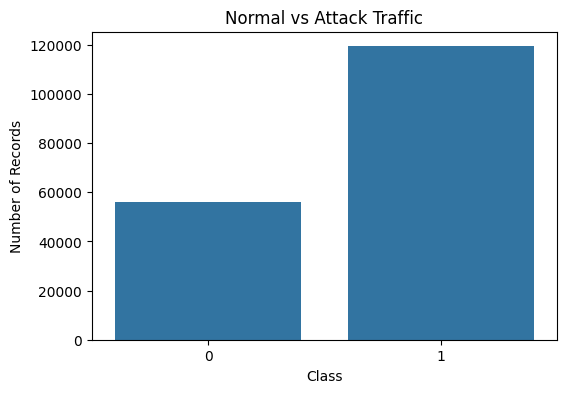

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x="label"
)

plt.title("Normal vs Attack Traffic")
plt.xlabel("Class")
plt.ylabel("Number of Records")

plt.show()

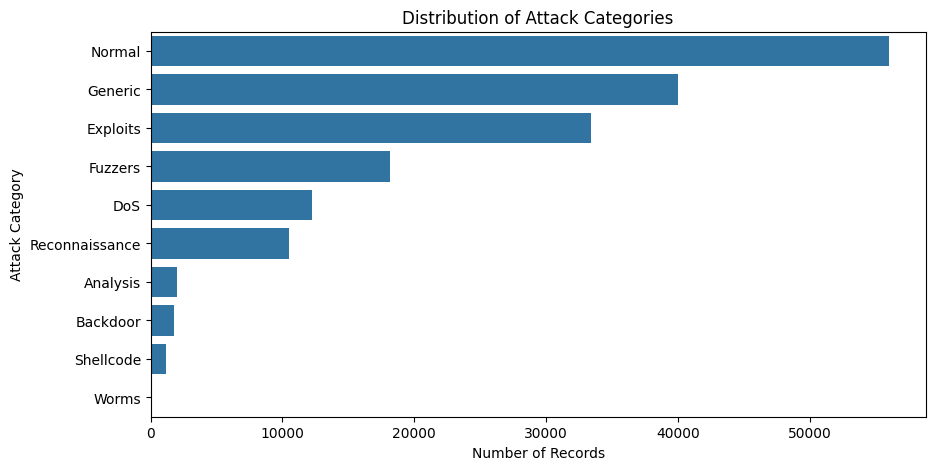

In [ ]:

plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    y="attack_cat",
    order=train_df["attack_cat"].value_counts().index
)

plt.title("Distribution of Attack Categories")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")

plt.show()

In [ ]:

missing = train_df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [ ]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0
